# J1.0: численный gate piecewise-SVF

Notebook читает замороженный synthetic batch и **не запускает регистрацию КТ**. Проверяются scaling-and-squaring, round-trip, региональный Jacobian и сохранение planar sliding. PASS означает только корректность численного представления; он не разрешает парные карты формы или толщины.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import Rectangle

result_root = ARTIFACT_ROOT / "results" / "piecewise_svf_j10_numeric_gate_v1"
config_path = repo_root / "configs" / "piecewise_svf_j10_numeric_gate_v1.json"
manifest_path = result_root / "manifest.json"

config = json.loads(config_path.read_text(encoding="utf-8"))
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
summary = pd.read_csv(result_root / "summary.csv")

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()

hash_checks = {
    "config": sha256(config_path) == manifest["config"]["sha256"],
    "summary": sha256(result_root / "summary.csv")
    == manifest["summary_sha256"],
}
for name, expected in manifest["field_sha256"].items():
    hash_checks[f"field:{name}"] = sha256(result_root / name) == expected
for name, expected in manifest["record_sha256"].items():
    hash_checks[f"record:{name}"] = sha256(result_root / name) == expected

if not all(hash_checks.values()):
    raise RuntimeError("Checksum batch-артефактов не совпадает с manifest")
if manifest["protocol_version"] != config["protocol_version"]:
    raise RuntimeError("Protocol version в config и manifest различается")

display(pd.Series(hash_checks, name="sha256_ok").to_frame())
display(
    pd.Series(
        {
            "protocol": manifest["protocol_version"],
            "code_version": manifest["code_version"],
            "cases": manifest["case_count"],
            "region_rows": manifest["region_row_count"],
            "all_pass": manifest["all_pass"],
        },
        name="manifest",
    ).to_frame()
)

,sha256_ok
config,True
summary,True
field:zero.npz,True
field:planar_sliding_translation.npz,True
field:diagonal_affine.npz,True
field:opposed_axial_rotation.npz,True
record:zero.json,True
record:planar_sliding_translation.json,True
record:diagonal_affine.json,True
record:opposed_axial_rotation.json,True


,manifest
protocol,piecewise-svf-j1.0-numeric-v1
code_version,d665a236d81ccc06338f10e1d0711c99e890f91c
cases,4
region_rows,8
all_pass,True


## Метрики по case и региону

Endpoint сравнивается с аналитической `exp(v)`, round-trip — с `exp(v) ∘ exp(-v)`, Jacobian считается отдельно для lung и body. Нулевой folding требуется без допуска.

endpoint_p95_mm  round_trip_p95_mm  \
case_id                    region                                       
zero                       lung           0.000000           0.000000   
                           body           0.000000           0.000000   
planar_sliding_translation lung           0.000000           0.000000   
                           body           0.000000           0.000000   
diagonal_affine            lung           0.000016           0.000031   
                           body           0.000009           0.000017   
opposed_axial_rotation     lung           0.000305           0.000610   
                           body           0.000119           0.000238   

                                   expected_jacobian  jacobian_p01  \
case_id                    region                                    
zero                       lung             1.000000      1.000000   
                           body             1.000000      1.000000   
planar_sliding_translation lung             1.000000      1.000000   
                           body             1.000000      1.000000   
diagonal_affine            lung             1.016129      1.016127   
                           body             1.000000      0.999999   
opposed_axial_rotation     lung             1.000000      1.000025   
                           body             1.000000      1.000010   

                                   jacobian_p01_abs_error  \
case_id                    region                           
zero                       lung              0.000000e+00   
                           body              0.000000e+00   
planar_sliding_translation lung              0.000000e+00   
                           body              0.000000e+00   
diagonal_affine            lung              1.242107e-06   
                           body              7.069146e-07   
opposed_axial_rotation     lung              2.489080e-05   
                           body              9.682669e-06   

                                   nonpositive_jacobian_fraction  gate_pass  \
case_id                    region                                             
zero                       lung                              0.0       True   
                           body                              0.0       True   
planar_sliding_translation lung                              0.0       True   
                           body                              0.0       True   
diagonal_affine            lung                              0.0       True   
                           body                              0.0       True   
opposed_axial_rotation     lung                              0.0       True   
                           body                              0.0       True   

                                   gate_reasons  
case_id                    region                
zero                       lung             NaN  
                           body             NaN  
planar_sliding_translation lung             NaN  
                           body             NaN  
diagonal_affine            lung             NaN  
                           body             NaN  
opposed_axial_rotation     lung             NaN  
                           body             NaN

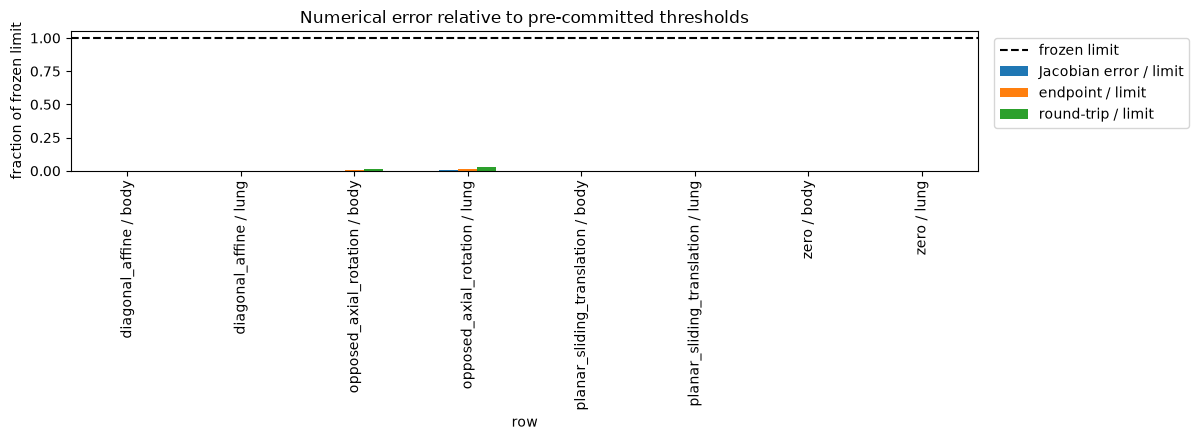

In [3]:
metric_columns = [
    "case_id",
    "region",
    "endpoint_p95_mm",
    "round_trip_p95_mm",
    "expected_jacobian",
    "jacobian_p01",
    "jacobian_p01_abs_error",
    "nonpositive_jacobian_fraction",
    "gate_pass",
    "gate_reasons",
]
display(summary[metric_columns].set_index(["case_id", "region"]))

thresholds = config["thresholds"]
ratios = summary[["case_id", "region"]].copy()
ratios["endpoint / limit"] = (
    summary["endpoint_p95_mm"] / thresholds["endpoint_p95_max_mm"]
)
ratios["round-trip / limit"] = (
    summary["round_trip_p95_mm"] / thresholds["round_trip_p95_max_mm"]
)
ratios["Jacobian error / limit"] = (
    summary["jacobian_p01_abs_error"]
    / thresholds["jacobian_abs_error_max"]
)
ratio_long = ratios.melt(
    id_vars=["case_id", "region"],
    var_name="metric",
    value_name="fraction_of_limit",
)
ratio_long["row"] = ratio_long["case_id"] + " / " + ratio_long["region"]
pivot = ratio_long.pivot(index="row", columns="metric", values="fraction_of_limit")
axis = pivot.plot.bar(figsize=(12, 4.5))
axis.axhline(1.0, color="black", linestyle="--", label="frozen limit")
axis.set_ylabel("fraction of frozen limit")
axis.set_title("Numerical error relative to pre-committed thresholds")
axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

## Проверка planar sliding

У двух регионов одинаковы нормальные компоненты переноса, но тангенциальные отличаются на 4 мм. Если transforms неявно смешиваются, slip уменьшится; если normal contact нарушен, появится mismatch.

In [4]:
sliding = summary[
    summary["case_id"] == "planar_sliding_translation"
][
    [
        "region",
        "normal_mismatch_p95_mm",
        "tangential_slip_truth_mm",
        "tangential_slip_observed_mm",
        "tangential_slip_error_mm",
        "nonpositive_jacobian_fraction",
        "gate_pass",
    ]
]
display(sliding.set_index("region"))

,normal_mismatch_p95_mm,tangential_slip_truth_mm,tangential_slip_observed_mm,tangential_slip_error_mm,nonpositive_jacobian_fraction,gate_pass
region,,,,,,
lung,0.0,4.0,4.0,0.0,0.0,True
body,0.0,4.0,4.0,0.0,0.0,True


## Граничный нюанс

Nearest extension сохраняет постоянный перенос, но для вращения за пределами массива нет наблюдаемого поля. Поэтому analytic gate заранее считает метрики во внутреннем прямоугольнике с отступом 8 вокселей. Ниже показана и вся плоскость, и реально оцениваемая область: это явное численное условие, а не утверждение об анатомии вне FOV.

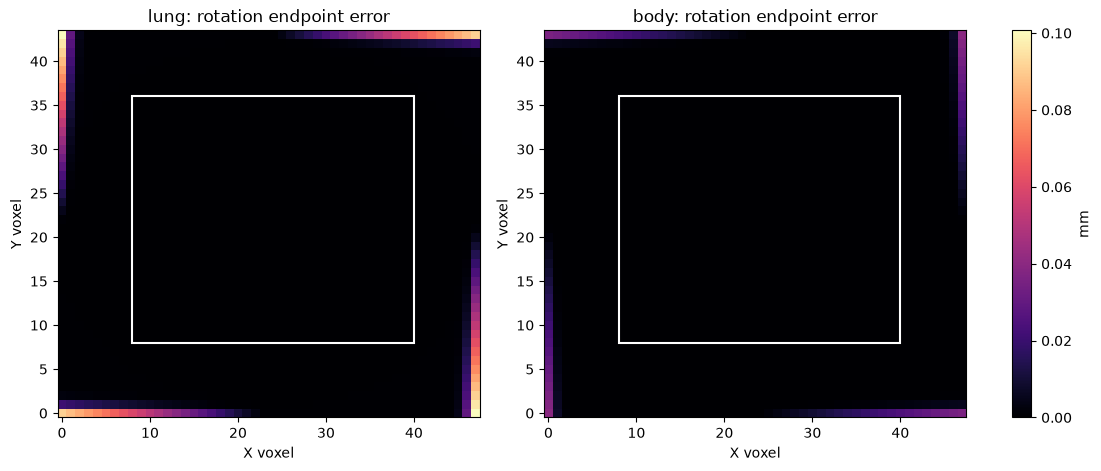

In [5]:
rotation = np.load(result_root / "opposed_axial_rotation.npz", allow_pickle=False)
errors = {}
for region in ("lung", "body"):
    estimate = rotation[f"{region}_displacement_mm"]
    truth = rotation[f"truth_{region}_displacement_mm"]
    errors[region] = np.linalg.norm(estimate - truth, axis=-1)

middle_z = errors["lung"].shape[2] // 2
margin_x, margin_y, _ = config["evaluation_margin_voxels"]
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
maximum = max(float(error[:, :, middle_z].max()) for error in errors.values())
for axis, (region, error) in zip(axes, errors.items(), strict=True):
    image = axis.imshow(
        error[:, :, middle_z].T,
        origin="lower",
        cmap="magma",
        vmin=0.0,
        vmax=maximum,
    )
    rectangle = Rectangle(
        (margin_x, margin_y),
        error.shape[0] - 2 * margin_x,
        error.shape[1] - 2 * margin_y,
        fill=False,
        edgecolor="white",
        linewidth=1.5,
    )
    axis.add_patch(rectangle)
    axis.set_title(f"{region}: rotation endpoint error")
    axis.set_xlabel("X voxel")
    axis.set_ylabel("Y voxel")
figure.colorbar(image, ax=axes, label="mm")
plt.show()

In [6]:
if not manifest["all_pass"] or not bool(summary["gate_pass"].all()):
    raise RuntimeError("J1.0 не прошёл frozen gate")
if int(summary["nonpositive_jacobian_fraction"].ne(0.0).sum()) != 0:
    raise RuntimeError("Обнаружен folding, несмотря на итог manifest")

worst_endpoint = float(summary["endpoint_p95_mm"].max())
worst_round_trip = float(summary["round_trip_p95_mm"].max())
display(
    Markdown(
        f"**J1.0 PASS: {manifest['region_pass_count']}/"
        f"{manifest['region_row_count']} региональных строк.** "
        f"Максимальный endpoint p95 = {worst_endpoint:.6f} мм, максимальный "
        f"round-trip p95 = {worst_round_trip:.6f} мм, folding = 0. "
        "Следующий шаг — J1.1 на криволинейном interface с gap/collision и "
        "отрицательными контролями. Этот PASS не проверяет image correspondence, "
        "не открывает Gate 1L и не разрешает карты изменения толщины/формы."
    )
)

**J1.0 PASS: 8/8 региональных строк.** Максимальный endpoint p95 = 0.000305 мм, максимальный round-trip p95 = 0.000610 мм, folding = 0. Следующий шаг — J1.1 на криволинейном interface с gap/collision и отрицательными контролями. Этот PASS не проверяет image correspondence, не открывает Gate 1L и не разрешает карты изменения толщины/формы.